# KernelEstimate: Predicting Ames, Iowa Home Sale Prices with Machine Learning

---
embed-resources: true
echo: false
---

---
format:
  html:
    toc: true
    toc-location: left
    toc-depth: 3
    number-sections: true
embed-resources: true
echo: false
---

## Introduction

The purpose of this report is to develop and evaluate a machine learning model that can estimate home sale prices for CornHawkHomes, an online real estate listing startup focused on the Ames, Iowa housing market. Accurate home value estimates are useful because buyers and sellers need a reasonable understanding of market value before making major financial decisions. In this lab scenario, the model will support KernelEstimate, an automated valuation tool designed to provide users with quick estimated home prices. 

The goal of the report is to explain the modeling process, evaluate the model’s predictive performance, and determine whether the selected model should be used in the real-world setting described in the lab. The data used for this analysis contains Ames, Iowa home sales from 2006 to 2010, with variables describing property size, quality, age, location, and other housing characteristics. The final model uses a preprocessing pipeline for missing values and categorical variables, followed by a Gradient Boosting regression model with a log-transformed sale price target.

## Methods

In [10]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn pipeline and preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# scikit-learn models and metrics
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error

# Model serialization
from joblib import dump

### Data

The data for this lab originally comes from the following publication:

De Cock, D. (2011). Ames, Iowa: Alternative to the Boston housing data as an end of semester regression project. Journal of Statistics Education, 19(3). [https://doi.org/10.1080/10691898.2011.11889627](https://doi.org/10.1080/10691898.2011.11889627)
However, the data from this paper has become a standard dataset in the machine learning community, and thus is also available via Kaggle:

- [Kaggle: Ames Iowa Housing Data](https://www.kaggle.com/datasets/marcopale/housing)

We have made modifications to the original data, including:
- Splitting the data into train, test, and production sets
- Withholding some data for the production data

In [11]:
# load data
housing_train = pd.read_parquet(
    "https://lab.cs307.org/housing/data/housing-train.parquet"
)

housing_test = pd.read_parquet(
    "https://lab.cs307.org/housing/data/housing-test.parquet"
)

### Data Dictionary

Each observation in the train, test, and (hidden) production data contains information about a particular home in Ames, Iowa that sold between 2006 and 2010.

Original and complete documentation for this data can be found on Kaggle.

### Variable Descriptions
 
**`SalePrice`**

- `[int64]` Sale price in USD.

**`Order`**

- `[int64]` Observation number.

**`PID`**

- `[int64]` Parcel identification number - can be used with city web site for parcel review.

**`MS SubClass`**

- `[int64]` Identifies the type of dwelling involved in the sale.

**`MS Zoning`**

- `[object]` Identifies the general zoning classification of the sale.

**`Lot Frontage`**

- `[float64]` Linear feet of street connected to property.

**`Lot Area`**

- `[int64]` Lot size in square feet.

**`Street`**

- `[object]` Type of road access to property.

**`Alley`**

- `[object]` Type of alley access to property.

**`Lot Shape`**

- `[object]` General shape of property.

**`Land Contour`**

- `[object]` Flatness of the property.

**`Utilities`**

- `[object]` Type of utilities available.

**`Lot Config`**

- `[object]` Lot configuration.

**`Land Slope`**

- `[object]` Slope of property.

**`Neighborhood`**

- `[object]` Physical locations within Ames city limits (map available).

**`Condition 1`**

- `[object]` Proximity to various conditions.

**`Condition 2`**

- `[object]` Proximity to various conditions (if more than one is present).

**`Bldg Type`**

- `[object]` Type of dwelling.

**`House Style`**

- `[object]` Style of dwelling.

**`Overall Qual`**

- `[int64]` Rates the overall material and finish of the house.

**`Overall Cond`**

- `[int64]` Rates the overall condition of the house.

**`Year Built`**

- `[int64]` Original construction date.

**`Year Remod/Add`**

- `[int64]` Remodel date (same as construction date if no remodeling or additions).

**`Roof Style`**

- `[object]` Type of roof.

**`Roof Matl`**

- `[object]` Roof material.

**`Exterior 1st`**

- `[object]` Exterior covering on house.

**`Exterior 2nd`**

- `[object]` Exterior covering on house (if more than one material).

**`Mas Vnr Type`**

- `[object]` Masonry veneer type.

**`Mas Vnr Area`**

- `[float64]` Masonry veneer area in square feet.

**`Exter Qual`**

- `[object]` Evaluates the quality of the material on the exterior.

**`Exter Cond`**

- `[object]` Evaluates the present condition of the material on the exterior.

**`Foundation`**

- `[object]` Type of foundation.

**`Bsmt Qual`**

- `[object]` Evaluates the height of the basement.

**`Bsmt Cond`**

- `[object]` Evaluates the general condition of the basement.

**`Bsmt Exposure`**

- `[object]` Refers to walkout or garden level walls.

**`BsmtFin Type 1`**

- `[object]` Rating of basement finished area.

**`BsmtFin SF 1`**

- `[float64]` Type 1 finished square feet.

**`BsmtFin Type 2`**

- `[object]` Rating of basement finished area (if multiple types).

**`BsmtFin SF 2`**

- `[float64]` Type 2 finished square feet.

**`Bsmt Unf SF`**

- `[float64]` Unfinished square feet of basement area.

**`Total Bsmt SF`**

- `[float64]` Total square feet of basement area.

**`Heating`**

- `[object]` Type of heating.

**`Heating QC`**

- `[object]` Heating quality and condition.

**`Central Air`**

- `[object]` Central air conditioning.

**`Electrical`**

- `[object]` Electrical system.

**`1st Flr SF`**

- `[int64]` First Floor square feet.

**`2nd Flr SF`**

- `[int64]` Second floor square feet.

**`Low Qual Fin SF`**

- `[int64]` Low quality finished square feet (all floors).

**`Gr Liv Area`**

- `[int64]` Above grade (ground) living area square feet.

**`Bsmt Full Bath`**

- `[float64]` Basement full bathrooms.

**`Bsmt Half Bath`**

- `[float64]` Basement half bathrooms.

**`Full Bath`**

- `[int64]` Full bathrooms above grade.

**`Half Bath`**

- `[int64]` Half baths above grade.

**`Bedroom AbvGr`**

- `[int64]` Bedrooms above grade (does not include basement bedrooms).

**`Kitchen AbvGr`**

- `[int64]` Kitchens above grade.

**`Kitchen Qual`**

- `[object]` Kitchen quality.

**`TotRms AbvGrd`**

- `[int64]` Total rooms above grade (does not include bathrooms).

**`Functional`**

- `[object]` Home functionality (Assume typical unless deductions are warranted).

**`Fireplaces`**

- `[int64]` Number of fireplaces.

**`Fireplace Qu`**

- `[object]` Fireplace quality.

**`Garage Type`**

- `[object]` Garage location.

**`Garage Yr Blt`**

- `[float64]` Year garage was built.

**`Garage Finish`**

- `[object]` Interior finish of the garage.

**`Garage Cars`**

- `[float64]` Size of garage in car capacity.

**`Garage Area`**

- `[float64]` Size of garage in square feet.

**`Garage Qual`**

- `[object]` Garage quality.

**`Garage Cond`**

- `[object]` Garage condition.

**`Paved Drive`**

- `[object]` Paved driveway.

**`Wood Deck SF`**

- `[int64]` Wood deck area in square feet.

**`Open Porch SF`**

- `[int64]` Open porch area in square feet.

**`Enclosed Porch`**

- `[int64]` Enclosed porch area in square feet.

**`3Ssn Porch`**

- `[int64]` Three season porch area in square feet.

**`Screen Porch`**

- `[int64]` Screen porch area in square feet.

**`Pool Area`**

- `[int64]` Pool area in square feet.

**`Pool QC`**

- `[object]` Pool quality.

**`Fence`**

- `[object]` Fence quality.

**`Misc Feature`**

- `[object]` Miscellaneous feature not covered in other categories.

**`Misc Val`**

- `[int64]` Value of miscellaneous feature.

**`Mo Sold`**

- `[int64]` Month Sold (MM).

**`Yr Sold`**

- `[int64]` Year Sold (YYYY).

**`Sale Type`**

- `[object]` Type of sale.

**`Sale Condition`**

- `[object]` Condition of sale.

### Summary Statistics

There are 1875 samples and 81 features in the training data.

In [12]:
train_shape = housing_train.drop("SalePrice", axis=1)
train_shape.shape

(1875, 81)

### Exploratory Visualization


#### 1. Distribution of home sale prices plot

@fig-sale-price-distribution shows that SalePrice is right-skewed. Most homes sold between roughly $100,000 and $250,000, while a smaller number of homes sold at much higher prices. This pattern suggests that expensive homes may have a large influence on model training if the target variable is used in its original scale.

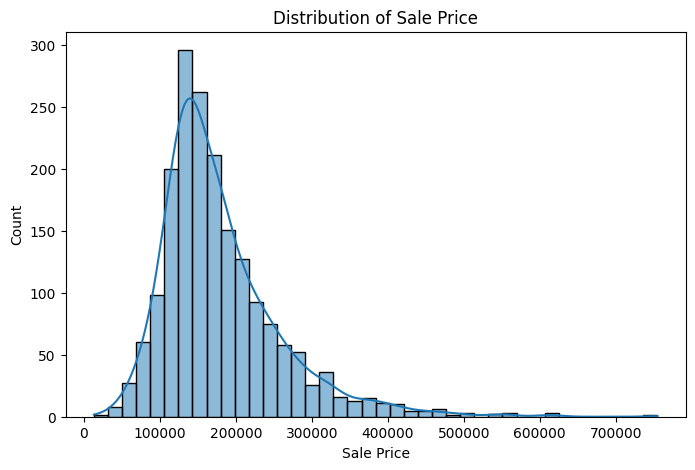

In [13]:
#| label: fig-sale-price-distribution
#| fig-cap: "Distribution of home sale prices in the Ames, Iowa training data, measured in U.S. dollars."

plt.figure(figsize=(8, 5))
sns.histplot(housing_train["SalePrice"], bins=40, kde=True)
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.title("Distribution of Sale Price")
plt.show()

#### 2. Distribution of log-transformed sale prices plot

@fig-log-sale-price-distribution shows that the log-transformed SalePrice distribution is much more symmetric than the original SalePrice distribution. This supports using a log transformation for the target variable during modeling. Since the lab evaluates performance using percentage-based error metrics, modeling log SalePrice can help the model focus more on relative error instead of only dollar error.

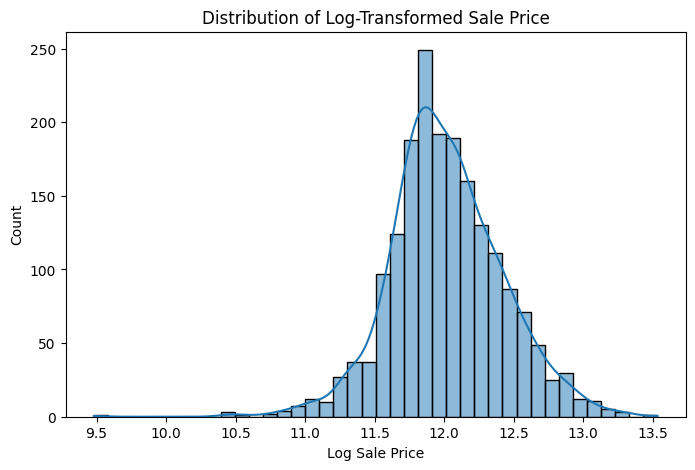

In [14]:
#| label: fig-log-sale-price-distribution
#| fig-cap: "Distribution of log-transformed home sale prices in the Ames, Iowa training data."

plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(housing_train["SalePrice"]), bins=40, kde=True)
plt.xlabel("Log Sale Price")
plt.ylabel("Count")
plt.title("Distribution of Log-Transformed Sale Price")
plt.show()

#### 3. Home sale prices by overall material and finish quality rating plot

Figure @fig-sale-price-overall-quality shows a clear positive relationship between Overall Qual and SalePrice. Homes with higher overall material and finish quality generally have much higher median sale prices. This indicates that Overall Qual is likely one of the most important predictors in the model.

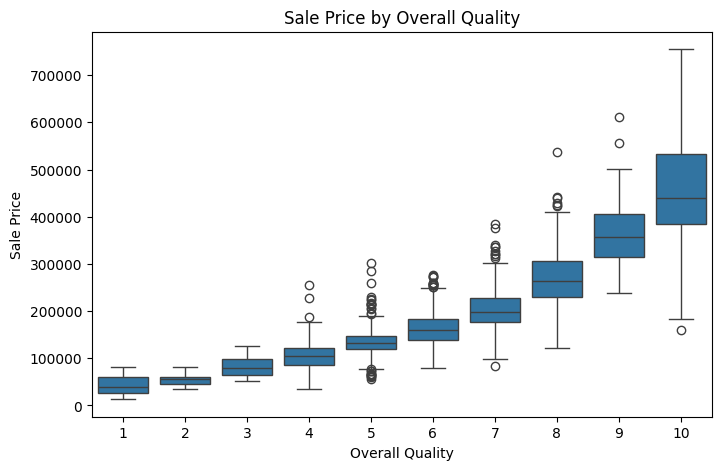

In [15]:
#| label: fig-sale-price-overall-quality
#| fig-cap: "Home sale prices by overall material and finish quality rating in the Ames, Iowa training data."

plt.figure(figsize=(8, 5))
sns.boxplot(data=housing_train, x="Overall Qual", y="SalePrice")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Sale Price by Overall Quality")
plt.show()

#### 4. SalePrice vs. Above Grade Living Area

Figure @fig-sale-price-living-area shows that larger homes generally sell for higher prices. However, the relationship is not perfectly linear, and there are some large homes with relatively low sale prices. This suggests that living area is important, but other variables such as quality, age, and location are also needed to explain home values accurately.

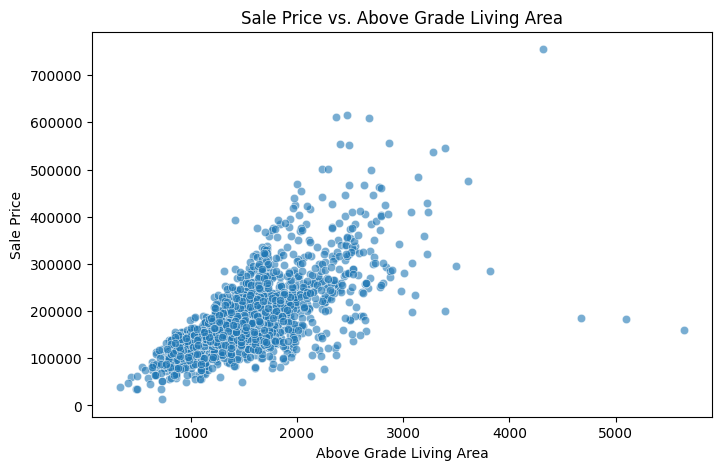

In [16]:
#| label: fig-sale-price-living-area
#| fig-cap: "Relationship between home sale price and above-grade living area in the Ames, Iowa training data."

plt.figure(figsize=(8, 5))
sns.scatterplot(data=housing_train, x="Gr Liv Area", y="SalePrice", alpha=0.6)
plt.xlabel("Above Grade Living Area")
plt.ylabel("Sale Price")
plt.title("Sale Price vs. Above Grade Living Area")
plt.show()

#### 5. Missing value summary bar chart

@tbl-missing-summary provides the missing count and missing percentage for the variables with the most missing values. This table supports the need for an imputation step before fitting the machine learning model.

In [17]:
#| label: tbl-missing-summary
#| tbl-cap: "Top variables with missing values in the Ames, Iowa training data."

missing = (
    housing_train.isna().sum()
    .sort_values(ascending=False)
)

missing_percent = missing / len(housing_train) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

missing_summary[missing_summary["missing_count"] > 0].head(20)

,missing_count,missing_percent
Pool QC,1868,99.626667
Misc Feature,1804,96.213333
Alley,1752,93.440000
Fence,1512,80.640000
Mas Vnr Type,1140,60.800000
Fireplace Qu,929,49.546667
Lot Frontage,302,16.106667
Garage Qual,104,5.546667
Garage Yr Blt,104,5.546667
Garage Cond,104,5.546667


@fig-missing-values shows that several variables have missing values, especially `Pool QC`, `Misc Feature`, `Alley`, `Fence`, `Mas Vnr Type`, and `Fireplace Qu`. Many of these variables describe optional home features, so missing values may mean that the feature is not present rather than simply unknown. 

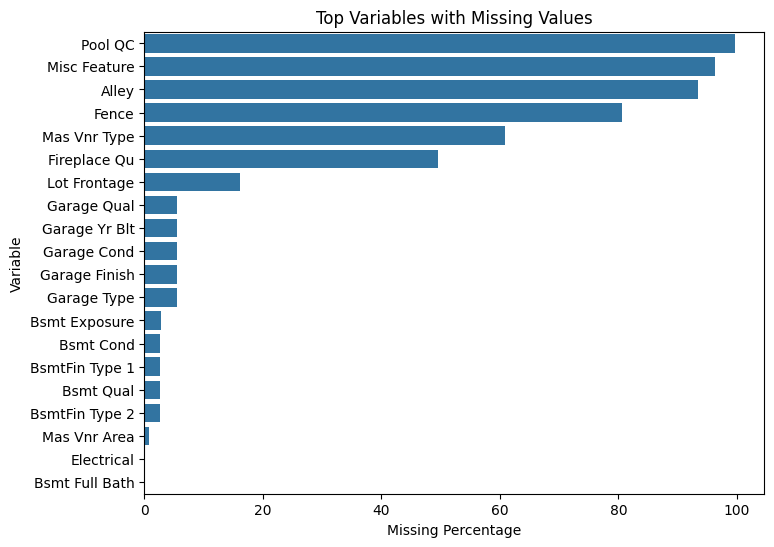

In [18]:
#| label: fig-missing-values
#| fig-cap: "Top variables with missing values in the Ames, Iowa training data, shown as percentages of observations."

top_missing = missing_summary[missing_summary["missing_count"] > 0].head(20)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_missing.reset_index(),
    x="missing_percent",
    y="index"
)
plt.xlabel("Missing Percentage")
plt.ylabel("Variable")
plt.title("Top Variables with Missing Values")
plt.show()

### Models

The goal of the modeling process was to build an automated valuation model that predicts home sale prices from property characteristics. I used the provided training set to fit the model and the provided test set to evaluate its predictive accuracy. The modeling pipeline includes preprocessing for missing values and categorical variables, followed by a gradient boosting regression model. This pipeline-based approach ensures that the same preprocessing steps are applied consistently during training, testing, and future production prediction.

#### 1. Create the X and y variants of the data for use with sklearn
To prepare the data for supervised machine learning, I separated the response variable from the predictor variables. The response variable is `SalePrice`, which represents the home sale price that the model is designed to estimate. All remaining columns were used as potential predictors because they describe property characteristics such as size, quality, age, location, and sale conditions. The provided training data was used to fit the model, while the provided test data was held out for evaluating predictive performance. 

In [19]:
X_train = housing_train.drop("SalePrice", axis=1)
y_train = housing_train["SalePrice"]

X_test = housing_test.drop("SalePrice", axis=1)
y_test = housing_test["SalePrice"]

#### 2. Drop ID-like columns

Before fitting the model, I removed `Order` and `PID` from the predictor set because these variables are identifiers rather than meaningful housing characteristics. `Order` represents the observation number, and `PID` is a parcel identification number. Although these variables may uniquely identify records, they do not directly describe features that should determine a home's market value. 

In [20]:
X_train = X_train.drop(["Order", "PID"], axis=1)
X_test = X_test.drop(["Order", "PID"], axis=1)

#### 3. Data Preprocessing

The predictor variables contain both numeric and categorical features, so I used separate preprocessing steps for each type of variable. Numeric variables were imputed using the median, which is appropriate for housing data because several numeric features may contain outliers. Categorical variables were imputed with a separate `"Missing"` category because missing values in housing data often indicate that a feature is not present, such as no alley access, no pool, or no fireplace. After imputation, categorical variables were converted into indicator variables using one-hot encoding so that they could be used by the machine learning model. Unknown categories were ignored during prediction to make the pipeline stable when new categories appear in the test or production data.

In [21]:
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

#### 4. Modeling and Training

For the final predictive model, I used a Gradient Boosting Regressor inside a full modeling pipeline. Gradient boosting is well suited for this task because home prices depend on nonlinear relationships and interactions among variables such as living area, overall quality, neighborhood, age, and property condition. 

I also transformed the target variable using `log1p(SalePrice)` during training and converted predictions back to dollars using the inverse transformation. This is useful because home sale prices are right-skewed, with a small number of very expensive homes. Modeling log sale price reduces the influence of extreme prices and makes the model focus more on relative prediction error. 

In [22]:
gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

model = Pipeline([
    ("preprocess", preprocess),
    ("regressor", TransformedTargetRegressor(
        regressor=gbr,
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

## Results

The final model was evaluated on the held-out test data using two performance metrics: mean absolute percentage error and the proportion of predictions within 20% of the true sale price. MAPE measures the average prediction error as a percentage of the actual sale price, while the 20% threshold metric measures how often the model produces a practically close estimate for an individual home.

In [23]:
# report model metrics

def proportion_within_threshold(y_true, y_pred, threshold=0.20):
    return np.mean((np.abs(y_pred - y_true) / y_true) <= threshold)


test_mape = mean_absolute_percentage_error(y_test, pred)
test_within_20 = proportion_within_threshold(y_test, pred)

print("Test MAPE:", test_mape)
print("Test proportion within 20%:", test_within_20)

Test MAPE: 0.07948641041828325
Test proportion within 20%: 0.9339019189765458


The final Gradient Boosting model achieved a test MAPE of 0.0795, meaning that its predictions were off by about 7.95% on average. The model also predicted 93.39% of test-set home prices within 20% of their true sale price. These results meet the lab target of test MAPE below 0.085 and test proportion within 20% above 0.92. Overall, the model provides reasonably accurate home value estimates for the Ames, Iowa housing data. 

### Summary Figure

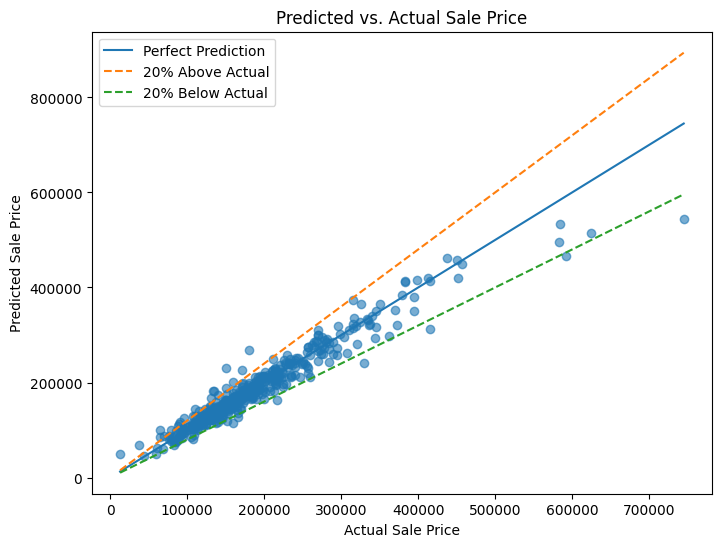

In [24]:
#| label: fig-predicted-vs-actual
#| fig-cap: "Predicted versus actual home sale prices for the test data, with reference lines showing perfect predictions and the 20% error range."

results_df = pd.DataFrame({
    "Actual Sale Price": y_test,
    "Predicted Sale Price": pred
})

plt.figure(figsize=(8, 6))

plt.scatter(
    results_df["Actual Sale Price"],
    results_df["Predicted Sale Price"],
    alpha=0.6
)

min_price = min(results_df["Actual Sale Price"].min(), results_df["Predicted Sale Price"].min())
max_price = max(results_df["Actual Sale Price"].max(), results_df["Predicted Sale Price"].max())
price_line = np.linspace(min_price, max_price, 100)

plt.plot(price_line, price_line, label="Perfect Prediction")
plt.plot(price_line, 1.2 * price_line, linestyle="--", label="20% Above Actual")
plt.plot(price_line, 0.8 * price_line, linestyle="--", label="20% Below Actual")

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Predicted vs. Actual Sale Price")
plt.legend()
plt.show()

@fig-predicted-vs-actual compares the model’s predicted sale prices with the actual sale prices in the test data. Points closer to the solid diagonal line represent more accurate predictions. Most points fall between the two dashed lines, which shows that most predictions were within 20% of the true sale price. This supports the numerical result that 93.39% of test-set predictions were within the 20% threshold.

In [25]:
# serialize model
dump(model, "housing.joblib", compress=9)

['housing.joblib']

## Discussion

Based on the test results, I would use the final Gradient Boosting model for the real-world scenario described in this lab, but with important limitations. The goal of CornHawkHomes is to provide an automated estimate of home sale prices for users through KernelEstimate, similar to how online real estate platforms provide automated valuation models. The lab also explains that automated valuations can give users quick access to market information, but home price prediction is difficult because prices depend on many factors such as location, size, age, condition, features, and local market conditions. 

The model provides a clear practical benefit. On the test data, the model achieved a MAPE of 0.0795, meaning that its predictions were off by about 7.95% on average. It also predicted 93.39% of test-set home prices within 20% of the true sale price. These results meet the required test performance targets for the lab. 

In practice, this means KernelEstimate could give buyers and sellers a useful starting point for understanding a home’s market value. For buyers, the estimate could help them decide whether a listing price is reasonable. For sellers, it could help them set an initial asking price before consulting an agent or appraiser. 

However, I would not use this model as the only source for making high-stakes real estate decisions. A home purchase is a major financial decision, and the lab notes that understanding fair market value is important for both buyers and sellers. Even though the model performs well on average, some individual predictions will still be wrong. This is especially important for higher-priced homes, where the predicted-versus-actual visualization shows more spread. A 10% error on a $100,000 home is $10,000, but a 10% error on a $500,000 home is $50,000. Therefore, users should treat the model output as an estimate, not a guaranteed sale price.

Another limitation is that the model is trained on Ames, Iowa housing sales from 2006 to 2010, while the lab scenario assumes the current year is 2011. This makes the model reasonable for the lab setting, but it may not generalize well to future housing markets without updates. Housing prices can change over time because of interest rates, local economic conditions, supply and demand, school quality, and neighborhood development. If CornHawkHomes wanted to use this model in production, the company should regularly retrain it with newer sales data.

Overall, I would recommend putting this model into practice as an initial version of KernelEstimate because it meets the lab’s accuracy goals and provides useful automated price estimates. However, I would use it as a decision-support tool rather than a final pricing authority. 

Future work should focus on adding prediction intervals, improving feature engineering, updating the model with newer market data, and testing performance across different price ranges and neighborhoods.

In [26]:
point_results = pd.DataFrame({
    "Actual Sale Price": y_test,
    "Predicted Sale Price": pred
})

point_results.head()

,Actual Sale Price,Predicted Sale Price
0,284000,270723.660637
1,108480,105027.491820
2,394432,349480.591617
3,150000,162181.804911
4,160000,114359.232792
